In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from IPython.display import display


Exploratory Data Analysis is done before data cleaning , means it is performed on the oroginal data

In [4]:
df = pd.read_csv('../data/Reclamations.csv')

In [5]:
df.head()

,id,date,wilaya,canal,texte_reclamation,categorie,sentiment,urgence,status,suggested_action
0,105001,2024-07-31,Tizi Ouzou,Centre d'appel,Incident: modem ne se synchronise pas.,Coupure de ligne,Négatif,Moyenne,Résolu,Redémarrage du modem
1,105002,2024-10-29,Boumerdès,Application mobile,Client signale problème lors de la résiliation...,Résiliation,Négatif,Moyenne,En cours,Vérifier décodeur
2,105003,2024-03-22,Msila,Site web,Demande d'assistance: bruit important sur la l...,Coupure de ligne,Négatif,Basse,Résolu,Envoi technicien
3,105004,2024-04-15,Saïda,Centre d'appel,"Incident: problème lors de la résiliation, fac...",Coupure de ligne,Négatif,Moyenne,Nouveau,Vérifier décodeur
4,105005,2025-09-04,Boumerdès,Site web,Incident: installation non réalisée dans les d...,Coupure de ligne,Négatif,Basse,Clôturé,Vérifier décodeur


In [6]:
def display_counts(df, column):
    table = df[column].value_counts().reset_index()
    table.columns = [column.capitalize(), "Count"]
    display(table)

print(f"\n {"Category Distribution"}")
display_counts(df, "categorie")
print(f"\n {"Channel Distribution"} ")
display_counts(df, "canal")
print(f"\n {"Region Distribution"} ")
display_counts(df, "wilaya")
print(f"\n {"Urgency Distribution"} ")
display_counts(df, "urgence")
print(f"\n {"Status Distribution"} ")
display_counts(df, "status")


 Category Distribution


,Categorie,Count
0,Coupure de ligne,22375
1,Internet lent,20034
2,Facturation,11891
3,Télévision,10021
4,Installation,9871
5,Assistance,7908
6,Résiliation,6101
7,Problème matériel,5879
8,Configuration,3954
9,Autre,1966



 Channel Distribution 


,Canal,Count
0,Centre d'appel,39649
1,Site web,20085
2,Agence commerciale,15206
3,Application mobile,15025
4,Email,10035



 Region Distribution 


,Wilaya,Count
0,Jijel,3832
1,Laghouat,3814
2,Annaba,3778
3,Batna,3757
4,Oran,3751
5,Biskra,3749
6,Tizi Ouzou,3749
7,Béjaïa,3743
8,Blida,3740
9,Mostaganem,3739



 Urgency Distribution 


,Urgence,Count
0,Moyenne,40136
1,Basse,39839
2,élevée,15131
3,Critique,4894



 Status Distribution 


,Status,Count
0,Résolu,35003
1,En cours,29960
2,Nouveau,25005
3,Escaladé,5072
4,Clôturé,4960


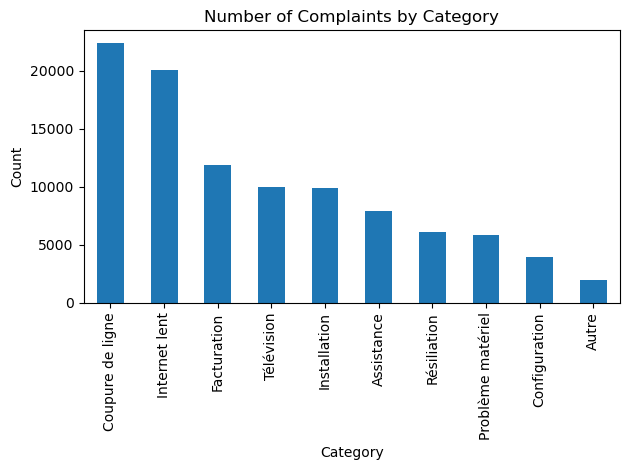

In [7]:
df["categorie"].value_counts().plot(kind="bar")
plt.title("Number of Complaints by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

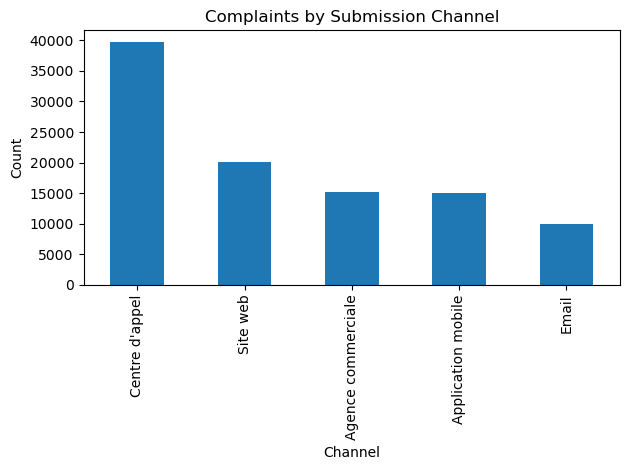

In [9]:
df["canal"].value_counts().plot(kind="bar")
plt.title("Complaints by Submission Channel")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

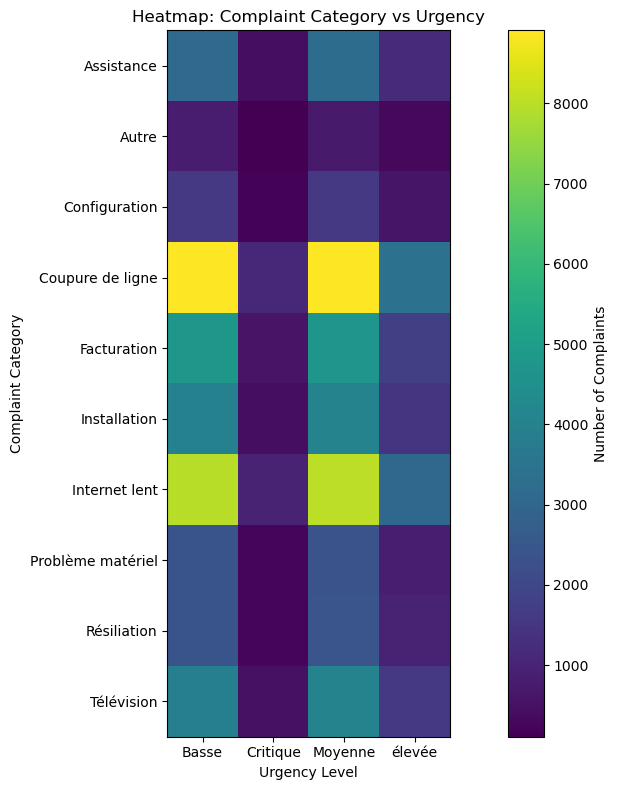

In [15]:

heatmap_data = (
    df.groupby(["categorie", "urgence"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_data)

plt.colorbar(label="Number of Complaints")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.xlabel("Urgency Level")
plt.ylabel("Complaint Category")
plt.title("Heatmap: Complaint Category vs Urgency")

plt.tight_layout()
plt.show()
